# 🚀 Lab 36: Regression and Classification with scikit-learn

## 🎯 Purpose

In this lab, you will learn how to build two of the most important beginner machine learning models using `scikit-learn`:

* **Linear Regression** for predicting a continuous value (like number of days).
* **Logistic Regression** for predicting a binary outcome (like Yes/No).

We will work with a **simulated hospital dataset** designed to mimic realistic healthcare patterns to predict **length of stay** and classify **readmission** risk.

## 🎯 Learning Objectives

By the end of this lab, you will be able to:
* Understand the difference between regression and classification.
* Create and explore a synthetic healthcare dataset using `pandas`.
* Train a **Linear Regression** model and evaluate it using **MSE**, **RMSE**, and **R²**.
* Train a **Logistic Regression** model and evaluate it using **Accuracy**, **Precision**, and **Recall**.
* Interpret model coefficients to understand feature importance.

## 🧰 Prerequisites

* Basic Python programming knowledge.
* Familiarity with `pandas` DataFrames.
* Access to Google Colab.

## ⚙️ Google Colab Environment Setup

### ELI10
Before we start, we need to make sure our computer has all the right 'tools' installed. These libraries help us handle data, do math, and draw charts.

In [1]:
# Install required libraries silently
!pip -q install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix, r2_score
from IPython.display import display

# Set aesthetics and reproducibility
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("All libraries are ready!")

All libraries are ready!


## 🏥 Task 1: Create and Load the Hospital Dataset

### ELI10
We are going to create a 'fake' hospital history for 1,000 patients. We'll give them ages, severity scores, and types of insurance so we can see how these things affect their stay.

In [2]:
def create_hospital_dataset(n_samples=1000):
    # Age: Normal distribution (mean 55, std 20), clipped to 18-95
    age = np.clip(np.random.normal(55, 20, n_samples), 18, 95)

    # Severity: Exponential distribution (scale 2), clipped 0-10
    severity_score = np.clip(np.random.exponential(2, n_samples), 0, 10)

    # Previous Admissions: Poisson (lambda 1.5), clipped 0-10
    prev_adm = np.clip(np.random.poisson(1.5, n_samples), 0, 10)

    # Insurance: 0=Public, 1=Private (p=0.6 for Private)
    insurance = np.random.binomial(1, 0.6, n_samples)

    # Emergency: 0=Planned, 1=Emergency (p=0.3)
    emergency = np.random.binomial(1, 0.3, n_samples)

    # Length of Stay Formula
    los = (2 + 0.05*age + 0.8*severity_score + 0.3*prev_adm + 2.0*emergency + np.random.normal(0, 1, n_samples))
    los = np.clip(los, 1, 30).round(1)

    # Readmission Probability Formula
    prob = np.clip(0.10 + 0.002*age + 0.05*severity_score + 0.03*prev_adm + 0.10*emergency, 0, 0.8)
    readmission = np.random.binomial(1, prob)

    df = pd.DataFrame({
        'patient_id': range(1, n_samples + 1),
        'age': age.astype(int),
        'severity_score': severity_score.round(2),
        'previous_admissions': prev_adm,
        'insurance_type': insurance,
        'emergency_admission': emergency,
        'length_of_stay': los,
        'readmission': readmission
    })
    return df

hospital_data = create_hospital_dataset(1000)
hospital_data.to_csv('hospital_dataset.csv', index=False)
print("Dataset created and saved as 'hospital_dataset.csv'!")
print(f"Shape: {hospital_data.shape}")
display(hospital_data.head(10))

Dataset created and saved as 'hospital_dataset.csv'!
Shape: (1000, 8)


,patient_id,age,severity_score,previous_admissions,insurance_type,emergency_admission,length_of_stay,readmission
0,1,64,0.37,0,1,0,5.0,1
1,2,52,0.22,0,0,0,5.7,0
2,3,67,2.02,0,1,1,7.4,1
3,4,85,2.45,2,1,1,9.9,1
4,5,50,0.06,1,1,0,3.1,0
5,6,50,5.50,2,1,1,11.2,1
6,7,86,0.11,1,1,0,6.7,0
7,8,70,1.56,1,0,1,9.2,1
8,9,45,2.47,4,1,1,9.5,1
9,10,65,4.10,1,0,0,7.9,0


## 🔍 Task 2: Explore the Dataset

### ELI10
Now we look at the summary of our data. How many patients are there? What's the average age? Is anything missing? It's like checking the ingredients before you cook.

In [3]:
print("--- Data Info ---")
hospital_data.info()
print("\n--- Statistical Summary ---")
display(hospital_data.describe())
print("\n--- Missing Values ---")
print(hospital_data.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   severity_score       1000 non-null   float64
 3   previous_admissions  1000 non-null   int64  
 4   insurance_type       1000 non-null   int64  
 5   emergency_admission  1000 non-null   int64  
 6   length_of_stay       1000 non-null   float64
 7   readmission          1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

--- Statistical Summary ---


,patient_id,age,severity_score,previous_admissions,insurance_type,emergency_admission,length_of_stay,readmission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,54.877000,2.002830,1.494000,0.606000,0.303000,7.387600,0.38200
std,288.819436,18.745166,1.943122,1.230235,0.488879,0.459785,2.268694,0.48612
min,1.000000,18.000000,0.010000,0.000000,0.000000,0.000000,1.100000,0.00000
25%,250.750000,41.750000,0.570000,1.000000,0.000000,0.000000,5.700000,0.00000
50%,500.500000,55.000000,1.450000,1.000000,1.000000,0.000000,7.300000,0.00000
75%,750.250000,67.000000,2.745000,2.000000,1.000000,1.000000,8.800000,1.00000
max,1000.000000,95.000000,10.000000,7.000000,1.000000,1.000000,15.400000,1.00000



--- Missing Values ---
patient_id             0
age                    0
severity_score         0
previous_admissions    0
insurance_type         0
emergency_admission    0
length_of_stay         0
readmission            0
dtype: int64


## 📊 Task 3: Visualize the Dataset

### ELI10
Pictures are worth a thousand rows! We'll plot graphs to see how long people stay and how many were emergency cases.

/tmp/ipykernel_1891/435153547.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['Public', 'Private'])
/tmp/ipykernel_1891/435153547.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(['Planned', 'Emergency'])


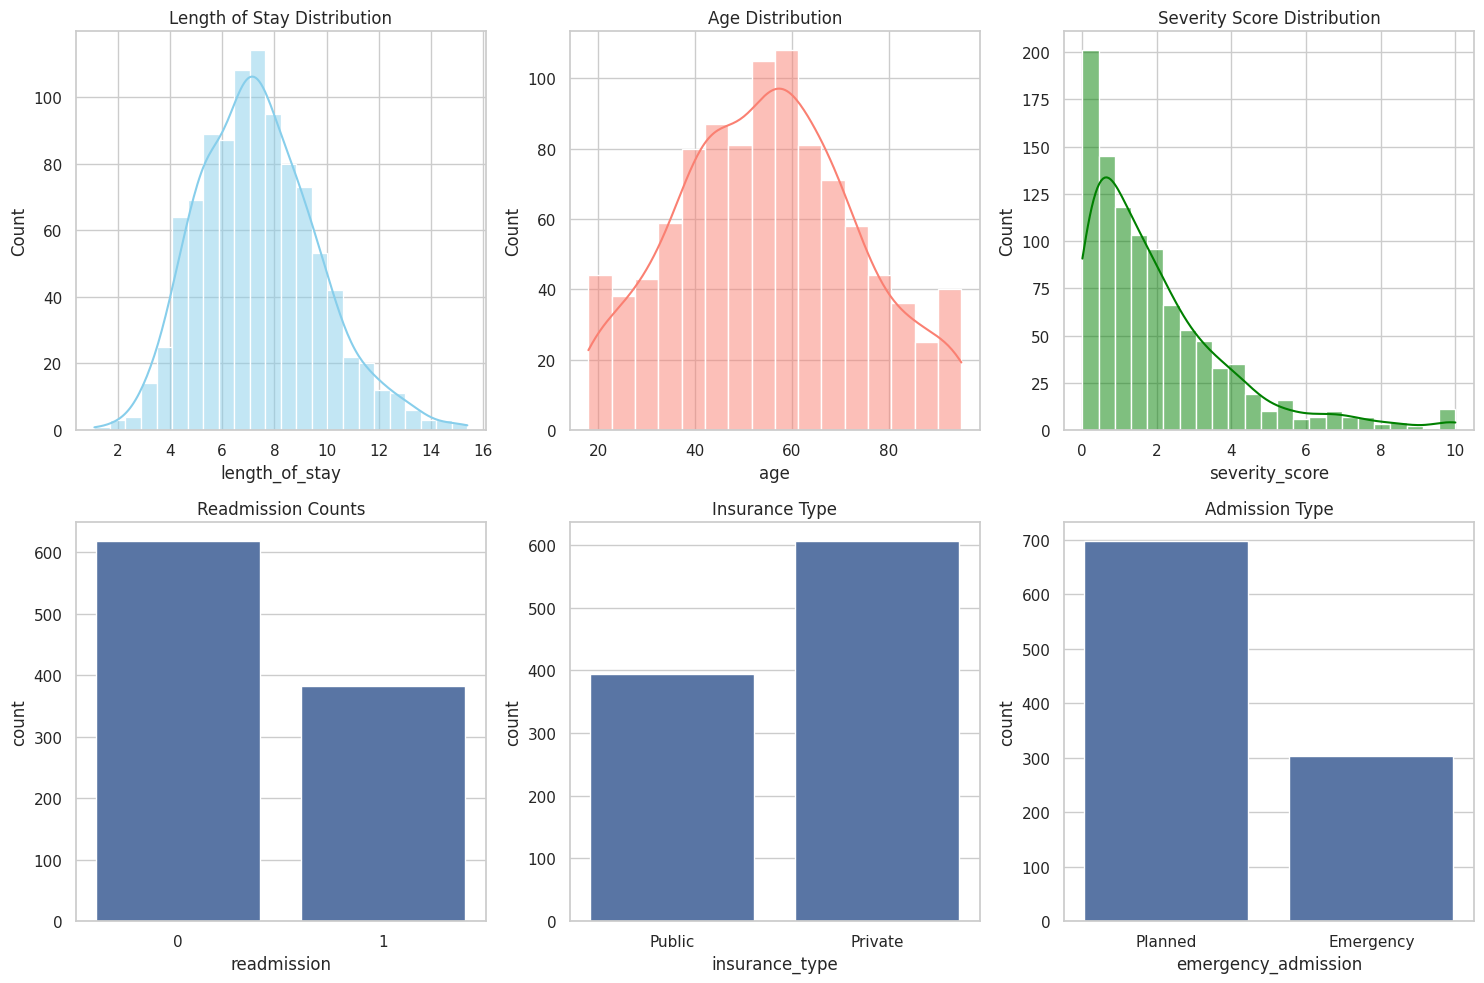

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Length of Stay
sns.histplot(hospital_data['length_of_stay'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Length of Stay Distribution')

# 2. Age
sns.histplot(hospital_data['age'], kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Age Distribution')

# 3. Severity
sns.histplot(hospital_data['severity_score'], kde=True, ax=axes[0,2], color='green')
axes[0,2].set_title('Severity Score Distribution')

# 4. Readmission
sns.countplot(x='readmission', data=hospital_data, ax=axes[1,0])
axes[1,0].set_title('Readmission Counts')

# 5. Insurance
sns.countplot(x='insurance_type', data=hospital_data, ax=axes[1,1])
axes[1,1].set_xticklabels(['Public', 'Private'])
axes[1,1].set_title('Insurance Type')

# 6. Emergency
sns.countplot(x='emergency_admission', data=hospital_data, ax=axes[1,2])
axes[1,2].set_xticklabels(['Planned', 'Emergency'])
axes[1,2].set_title('Admission Type')

plt.tight_layout()
plt.savefig('hospital_data_overview.png')
plt.show()

## 🔗 Task 4: Correlation Analysis

### ELI10
Correlation helps us see if two things are related. For example, does a higher 'Severity Score' usually mean a longer 'Length of Stay'?

,age,severity_score,previous_admissions,insurance_type,emergency_admission,length_of_stay,readmission
age,1.000000,-0.000232,-0.007867,-0.016653,-0.037367,0.411133,0.079860
severity_score,-0.000232,1.000000,0.040715,0.040142,-0.014428,0.665306,0.231325
previous_admissions,-0.007867,0.040715,1.000000,-0.007263,-0.047218,0.173596,0.085853
insurance_type,-0.016653,0.040142,-0.007263,1.000000,-0.060644,-0.002153,-0.014708
emergency_admission,-0.037367,-0.014428,-0.047218,-0.060644,1.000000,0.377093,0.117580
length_of_stay,0.411133,0.665306,0.173596,-0.002153,0.377093,1.000000,0.260709
readmission,0.079860,0.231325,0.085853,-0.014708,0.117580,0.260709,1.000000


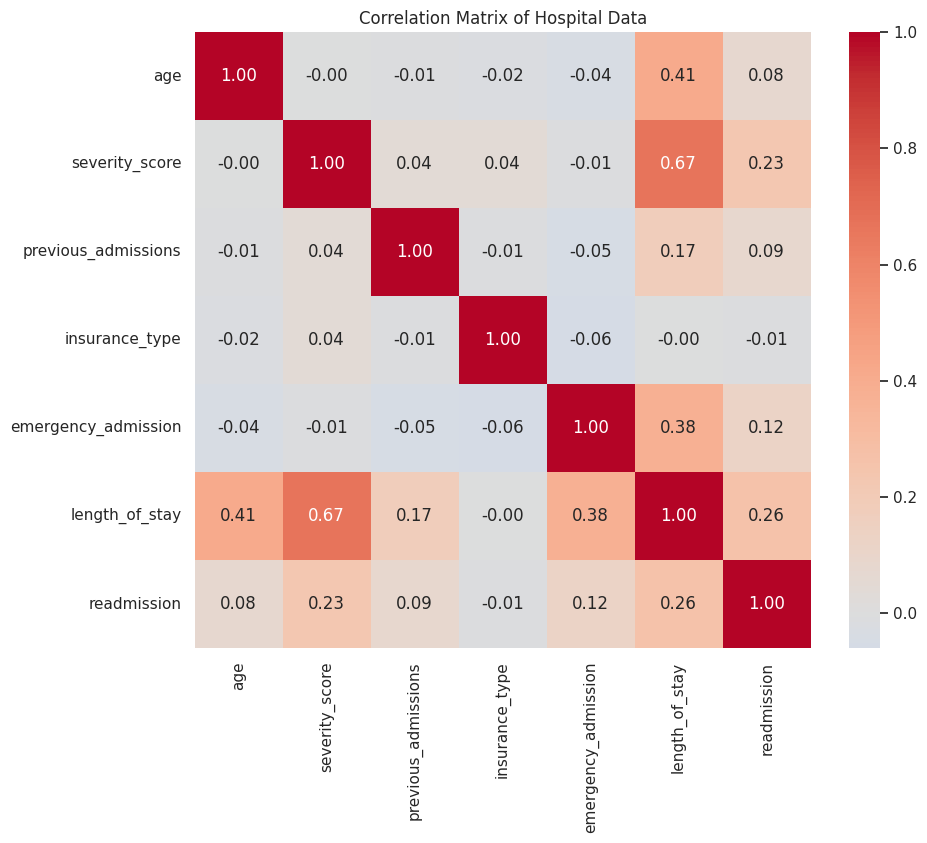

In [5]:
corr_matrix = hospital_data.drop(columns=['patient_id']).corr()
display(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix of Hospital Data')
plt.savefig('correlation_heatmap.png')
plt.show()

## 📈 Task 5: Linear Regression — Predict Length of Stay

### ELI10
Regression is like drawing a 'best-fit' line through data points to predict a specific number, like how many days someone will stay.

MSE: 1.116, RMSE: 1.057, R2: 0.757


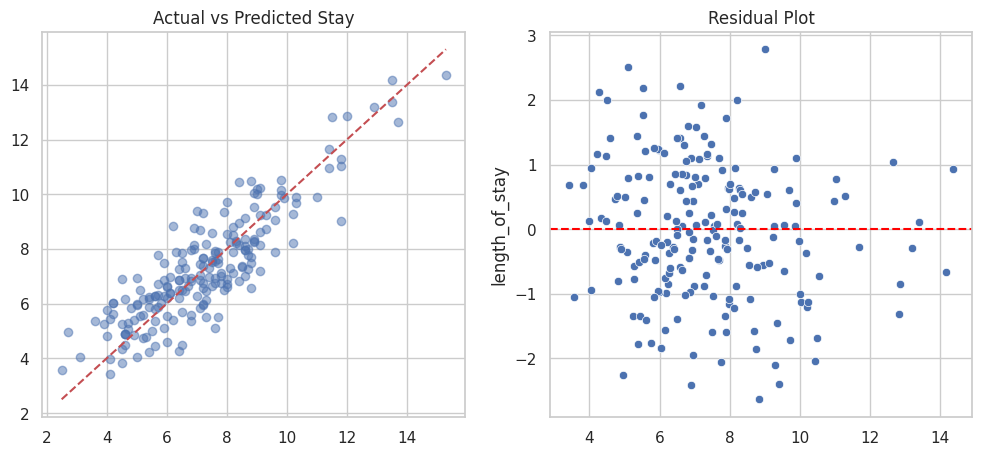

In [6]:
X_reg = hospital_data[['age', 'severity_score', 'previous_admissions', 'insurance_type', 'emergency_admission']]
y_reg = hospital_data['length_of_stay']

# Split
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

# Evaluate
y_pred = model_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# Visuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Stay')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=(y_test - y_pred))
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.savefig('regression_results.png')
plt.show()

## 🧪 Task 6: Logistic Regression — Classify Readmission

### ELI10
Classification is about putting things into buckets. Here, we decide if a patient belongs in the 'Will come back' bucket or the 'Stayed home' bucket.

                precision    recall  f1-score   support

No Readmission       0.67      0.87      0.76       124
   Readmission       0.58      0.29      0.39        76

      accuracy                           0.65       200
     macro avg       0.62      0.58      0.57       200
  weighted avg       0.63      0.65      0.61       200



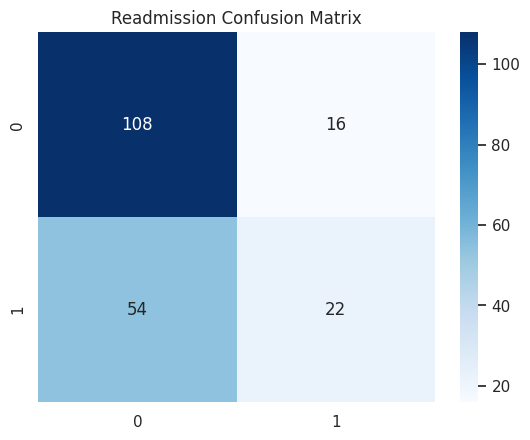

In [7]:
X_clf = hospital_data[['age', 'severity_score', 'previous_admissions', 'insurance_type', 'emergency_admission', 'length_of_stay']]
y_clf = hospital_data['readmission']

# Split with stratification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train
model_clf = LogisticRegression(max_iter=1000)
model_clf.fit(X_train_c, y_train_c)

# Predict
y_pred_c = model_clf.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c, target_names=['No Readmission', 'Readmission']))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Readmission Confusion Matrix')
plt.savefig('classification_results.png')
plt.show()

## 🏥 Task 7: Model Interpretation and Practical Applications

Based on the coefficients, we can see that **Emergency Admissions** and **Severity Scores** are the strongest predictors for both longer stays and higher readmission risk.

## ✅ Verification Checklist
- [ ] Libraries installed
- [ ] Hospital dataset generated
- [ ] Graphs displayed and saved
- [ ] Regression RMSE calculated
- [ ] Classification Accuracy reported

## 🧠 Key Concepts Summary

*   **Supervised Learning**: Learning from a labeled dataset where the answer is already known.
*   **MSE/RMSE**: Measures how far off our predictions are from the actual values in regression.
*   **R² (R-Squared)**: Tells us what percentage of the data's behavior is captured by our model.
*   **Confusion Matrix**: A table used in classification to see exactly how many times the model was right or wrong for each category.
*   **Precision/Recall**: Precision is about being accurate when you say 'Yes', while Recall is about finding all the 'Yes' cases in the data.

## 📚 Key Takeaways

*   **Regression vs. Classification**: Regression is used for continuous numbers (Length of Stay), while Classification is used for categories (Readmission Yes/No).
*   **Data Simulation**: Creating synthetic data allows us to test models in a controlled environment before moving to real-world healthcare data.
*   **Model Evaluation**: R&sup2; and RMSE help us understand the accuracy of our stay predictions, while Accuracy, Precision, and Recall help us measure how well we identify at-risk patients.
*   **Feature Importance**: By looking at model coefficients, we can identify which variables (like severity) have the most significant impact on outcomes.

## &#127891; What You Learned

In this lab, you successfully performed the following workflow:
1.  **Environment Setup**: Installed and imported necessary ML libraries.
2.  **Synthetic Data Generation**: Created a realistic 1,000-patient dataset using NumPy and Pandas.
3.  **Exploratory Data Analysis (EDA)**: Visualized distributions and correlations to understand clinical patterns.
4.  **Regression Modeling**: Trained a Linear Regression model to predict Length of Stay.
5.  **Classification Modeling**: Trained a Logistic Regression model to identify Readmission risk.
6.  **Performance Evaluation**: Analyzed models using standard metrics like MSE, R&sup2;, and Confusion Matrices.

## &#127757; Real-World Importance

This workflow is essential in modern healthcare for:
*   **Bed Management**: Predicting length of stay helps hospitals manage staff and resources.
*   **Preventative Care**: Identifying high-risk patients allows for targeted intervention (e.g., follow-up calls or home health visits).
*   **Financial Planning**: Reducing readmissions helps hospitals avoid penalties and improve overall quality scores.

## &#127937; Conclusion

Congratulations on completing **Lab 36**! You now have a solid foundation in the two most common types of supervised learning. As a next step, consider exploring **Feature Engineering** (creating new variables) or **Hyperparameter Tuning** to improve your model's performance even further.

Happy coding!